In [705]:
import pandas as pd


df = pd.read_excel("TB DATA.xlsx")

threshold = 0.1 * len(df)


df_cleaned = df.dropna(axis=1, thresh=threshold)


df_cleaned.to_excel("clean_tb_data.xlsx", index=False)

print("Columns with >90% null values removed. Cleaned file saved as 'tb_data_cleaned.xlsx'")


Columns with >90% null values removed. Cleaned file saved as 'tb_data_cleaned.xlsx'


In [706]:
df['Default or not'].value_counts(normalize=True)


Default or not
not-default    0.797972
default        0.202028
Name: proportion, dtype: float64

In [707]:
import pandas as pd

df = pd.read_excel("clean_tb_data.xlsx") 


print(df.head())


print(df.info())


print(df['Default or not'].value_counts(normalize=True))


  Default or not DiagnosingFacilityDistrict DiagnosingFacilityTBU  \
0    not-default          SPMH CHEST CLINIC      JPC HOSPITAL, SP   
1    not-default          SPMH CHEST CLINIC      JPC HOSPITAL, SP   
2    not-default                 PATPARGANJ       PATPARGANJ TU 2   
3    not-default                       NDMC             NDMC TU 1   
4    not-default            LN CHEST CLINIC      L N CHEST CLINIC   

                DiagnosingFacilityPHI DiagnosingFacilityPHIType  \
0       J.P.C. HOSPITAL, SHASTRI PARK                       PHI   
1       J.P.C. HOSPITAL, SHASTRI PARK                       PHI   
2  DR. SPM CHEST HOSPITAL, PATPARGANJ                       PHI   
3                     RMLH-CBNAAT LAB                       PHI   
4                  LOK NAYAK HOSPITAL                       PHI   

   DiagnosingFacilityPHI_ID  MONTH  YEAR   Treatment_Outcome  \
0                         1      2  2021               CURED   
1                         1      1  2021  TREATMENT_CO

In [708]:

target = 'Default or not'


feature_cols = ['Age', 'Weight', 'Gender', 'HIV_Status', 'DiabetesStatus',
                'TypeOfCase', 'SiteOfDisease',  
                'ContactTracing_Done','Patient_Status','Microbiologically_Confirmed']

X = df[feature_cols]
y = df[target]


In [709]:

numeric_cols = ['Age', 'Weight']
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())


categorical_cols = ['Gender', 'HIV_Status', 'DiabetesStatus', 'TypeOfCase', 
                    'SiteOfDisease', 'ContactTracing_Done','Patient_Status','Microbiologically_Confirmed']

X[categorical_cols] = X[categorical_cols].fillna('Unknown')


C:\Users\acer\AppData\Local\Temp\ipykernel_4996\3350600234.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())
C:\Users\acer\AppData\Local\Temp\ipykernel_4996\3350600234.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[categorical_cols] = X[categorical_cols].fillna('Unknown')


In [710]:
from sklearn.preprocessing import LabelEncoder

yes_no_cols = ['ContactTracing_Done','Microbiologically_Confirmed']
for col in yes_no_cols:
    X[col] = X[col].map({'Yes':1, 'No':0, 'Unknown':0})


multi_cat_cols = ['Gender','HIV_Status','DiabetesStatus','TypeOfCase','SiteOfDisease','Patient_Status']
for col in multi_cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))


C:\Users\acer\AppData\Local\Temp\ipykernel_4996\3378423914.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].map({'Yes':1, 'No':0, 'Unknown':0})
C:\Users\acer\AppData\Local\Temp\ipykernel_4996\3378423914.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].map({'Yes':1, 'No':0, 'Unknown':0})
C:\Users\acer\AppData\Local\Temp\ipykernel_4996\3378423914.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,c

In [711]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])


C:\Users\acer\AppData\Local\Temp\ipykernel_4996\677123846.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[numeric_cols] = scaler.fit_transform(X[numeric_cols])


In [712]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [713]:
y_train = y_train.map({'not-default':0, 'default':1}).astype('float32')
y_test  = y_test.map({'not-default':0, 'default':1}).astype('float32')


In [714]:
print(y_train.value_counts())


Default or not
0.0    4910
1.0    1243
Name: count, dtype: int64


In [715]:
from sklearn.utils import class_weight
import numpy as np

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(0.6265784114052954), 1: np.float64(2.4750603378921965)}


In [716]:
print(y_train.dtype)
print(y_train.unique())


float32
[0. 1.]


In [730]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam


input_dim = X_train.shape[1]

model = Sequential([
    Input(shape=(input_dim,)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary output
])

model.compile(
    optimizer = Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

model.summary()


Model: "sequential_79"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_312 (Dense)               │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_232 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_313 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_233 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_314 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_234 (Dropout)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_315 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_235 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_316 (Dense)               │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

In [731]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))


49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
[[  98 1130]
 [  17  294]]
              precision    recall  f1-score   support

           0       0.85      0.08      0.15      1228
           1       0.21      0.95      0.34       311

    accuracy                           0.25      1539
   macro avg       0.53      0.51      0.24      1539
weighted avg       0.72      0.25      0.18      1539

ROC-AUC: 0.5101333305403395


In [732]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    class_weight=class_weights
)


Epoch 1/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5055 - loss: 0.6885 - precision_55: 0.2143 - recall_55: 0.5454 - val_accuracy: 0.6239 - val_loss: 0.6812 - val_precision_55: 0.3221 - val_recall_55: 0.7649
Epoch 2/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5839 - loss: 0.6618 - precision_55: 0.2596 - recall_55: 0.5746 - val_accuracy: 0.8164 - val_loss: 0.6485 - val_precision_55: 0.5439 - val_recall_55: 0.6175
Epoch 3/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6650 - loss: 0.6299 - precision_55: 0.3160 - recall_55: 0.5685 - val_accuracy: 0.8481 - val_loss: 0.5951 - val_precision_55: 0.6684 - val_recall_55: 0.5060
Epoch 4/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7188 - loss: 0.6109 - precision_55: 0.3679 - recall_55: 0.5504 - val_accuracy: 0.8513 - val_loss: 0.5567 - val_precision_55: 0.6771 - val_recall_55: 0.5179
Epoch 5/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7523 - loss: 0.5926 - precision_55: 0.4108 - 

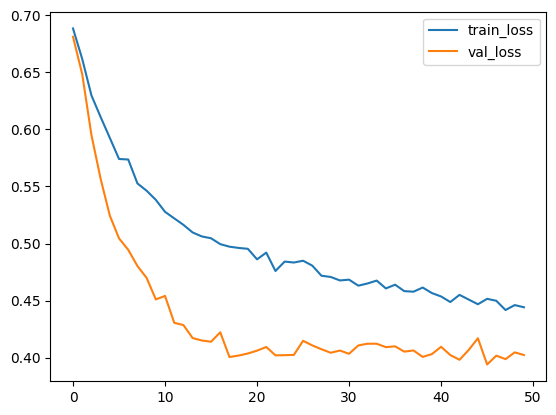

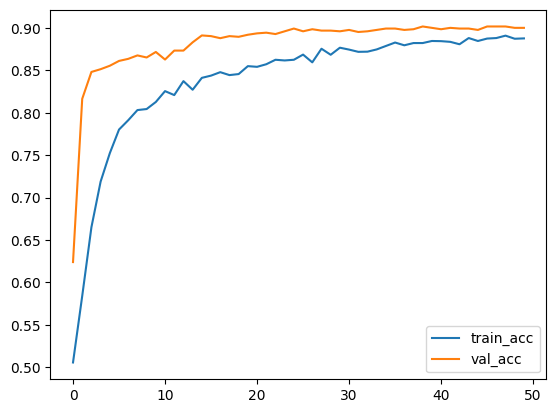

In [733]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()


In [734]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_prob = model.predict(X_test)


y_pred = (y_pred_prob > 0.5).astype(int)


print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


print("Classification Report:")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC Score:", roc_auc)


49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix:
[[1211   17]
 [  92  219]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      1228
           1       0.93      0.70      0.80       311

    accuracy                           0.93      1539
   macro avg       0.93      0.85      0.88      1539
weighted avg       0.93      0.93      0.93      1539

ROC-AUC Score: 0.8974386501461085


In [722]:
print(history.history['accuracy'])

[0.7368955612182617, 0.7379114031791687, 0.7637139558792114, 0.7728565335273743, 0.7893133163452148, 0.795611560344696, 0.8075985312461853, 0.799674928188324, 0.8116618990898132, 0.8167411684989929, 0.8084112405776978, 0.820398211479187, 0.8232426047325134, 0.8199918866157532, 0.8159284591674805, 0.8254774212837219, 0.8240552544593811, 0.8252742886543274, 0.828118622303009, 0.8435595035552979, 0.8358390927314758, 0.8396993279457092, 0.8407151699066162, 0.8368549346923828, 0.8417310118675232, 0.8429500460624695, 0.8480292558670044, 0.8459975719451904, 0.8437626957893372, 0.8466070890426636, 0.8453880548477173, 0.8439658880233765, 0.8453880548477173, 0.8466070890426636, 0.8500609397888184, 0.8478260636329651, 0.8587972521781921, 0.8555465340614319, 0.8590003848075867, 0.851483166217804, 0.8590003848075867, 0.8604226112365723, 0.8583909273147583, 0.8590003848075867, 0.8555465340614319, 0.8598130941390991, 0.8594067692756653, 0.858187735080719, 0.8618447780609131, 0.8667208552360535]


In [723]:
print(history.history['val_accuracy'])

[0.8342810869216919, 0.8285946249961853, 0.8302193284034729, 0.8334687352180481, 0.8424045443534851, 0.8432168960571289, 0.8456539511680603, 0.8472786545753479, 0.8505280017852783, 0.8497156500816345, 0.8505280017852783, 0.8562144637107849, 0.8554021120071411, 0.8562144637107849, 0.8562144637107849, 0.8610885739326477, 0.8610885739326477, 0.8659626245498657, 0.8716490864753723, 0.8757107853889465, 0.8765231370925903, 0.8789601922035217, 0.8805848956108093, 0.8822095990180969, 0.8805848956108093, 0.8789601922035217, 0.8813972473144531, 0.8789601922035217, 0.8797725439071655, 0.8765231370925903, 0.8789601922035217, 0.8805848956108093, 0.8789601922035217, 0.8797725439071655, 0.8805848956108093, 0.8805848956108093, 0.8781478404998779, 0.8813972473144531, 0.8773354887962341, 0.8805848956108093, 0.8797725439071655, 0.8805848956108093, 0.8805848956108093, 0.8789601922035217, 0.8773354887962341, 0.8846466541290283, 0.8805848956108093, 0.8822095990180969, 0.8797725439071655, 0.8805848956108093]

In [724]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Initialize and train
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train, y_train)

# Predict
y_pred_log = log_model.predict(X_test)
y_pred_log_prob = log_model.predict_proba(X_test)[:, 1]

# Evaluate
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_log_prob))
print(classification_report(y_test, y_pred_log))


Logistic Regression
Accuracy: 0.9226770630279402
ROC-AUC: 0.8903557924945275
              precision    recall  f1-score   support

         0.0       0.93      0.98      0.95      1228
         1.0       0.90      0.69      0.78       311

    accuracy                           0.92      1539
   macro avg       0.91      0.84      0.87      1539
weighted avg       0.92      0.92      0.92      1539



In [725]:
from sklearn.svm import SVC

# Train SVM with class weights
svm_model = SVC(kernel='rbf', probability=True, class_weight='balanced')
svm_model.fit(X_train, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test)
y_pred_svm_prob = svm_model.predict_proba(X_test)[:, 1]

# Evaluate
print("Support Vector Machine (SVM)")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_svm_prob))
print(classification_report(y_test, y_pred_svm))


Support Vector Machine (SVM)
Accuracy: 0.9252761533463287
ROC-AUC: 0.8788504037621626
              precision    recall  f1-score   support

         0.0       0.94      0.97      0.95      1228
         1.0       0.88      0.73      0.80       311

    accuracy                           0.93      1539
   macro avg       0.91      0.85      0.88      1539
weighted avg       0.92      0.93      0.92      1539



In [726]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)
y_pred_rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Evaluate
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_rf_prob))
print(classification_report(y_test, y_pred_rf))


Random Forest
Accuracy: 0.8960363872644574
ROC-AUC: 0.8875396692397122
              precision    recall  f1-score   support

         0.0       0.93      0.94      0.94      1228
         1.0       0.75      0.72      0.74       311

    accuracy                           0.90      1539
   macro avg       0.84      0.83      0.84      1539
weighted avg       0.89      0.90      0.90      1539



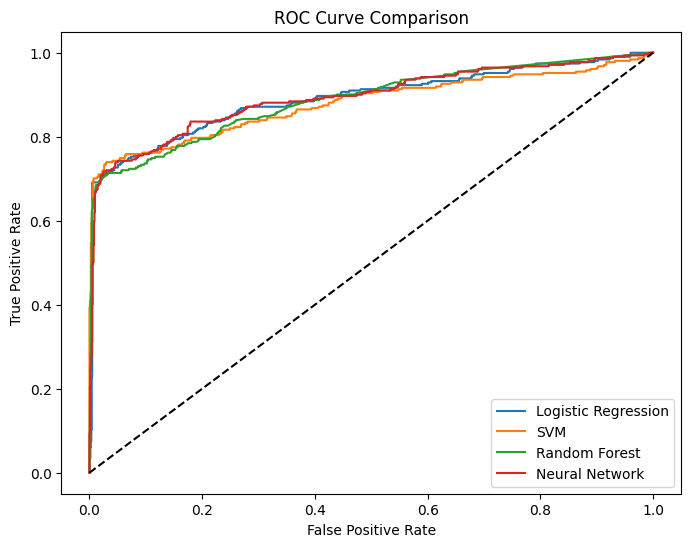

In [727]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_log_prob)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_svm_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf_prob)
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_pred_prob)  # from your neural model

plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label='Logistic Regression')
plt.plot(fpr_svm, tpr_svm, label='SVM')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot(fpr_nn, tpr_nn, label='Neural Network')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()


In [728]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.


In [729]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import class_weight
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, roc_curve
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

# --- Assume X_train, X_test, y_train, y_test are preprocessed ---
y_train = y_train.astype(int)
y_test  = y_test.astype(int)
input_dim = X_train.shape[1]

# --- Handle imbalance using SMOTE for classical ML and regression models ---
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# --- Classical classification models ---
class_models = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

# --- Regression models ---
reg_models = {
    "LinearRegression": LinearRegression(),
    "RidgeRegression": Ridge(),
    "LassoRegression": Lasso(),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=42)
}

# --- Neural Network ---
def build_nn(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# --- Compute class weights for NN ---
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(weights))

results = {}

# --- Function to calculate metrics with optimal threshold ---
def evaluate_model(y_test, y_prob):
    from sklearn.metrics import roc_auc_score, classification_report, f1_score
    from sklearn.metrics import roc_curve

    # Compute optimal threshold
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    optimal_idx = np.argmax(tpr - fpr)  # Youden's J statistic
    optimal_threshold = thresholds[optimal_idx]
    y_pred = (y_prob > optimal_threshold).astype(int)
    
    print("Optimal threshold:", optimal_threshold)
    
    # Compute metrics
    roc_auc = roc_auc_score(y_test, y_prob)
    accuracy = np.mean(y_pred == y_test)
    report = classification_report(y_test, y_pred, zero_division=0, output_dict=True)
    precision = report.get('1', {}).get('precision', 0)
    recall = report.get('1', {}).get('recall', 0)
    f1 = f1_score(y_test, y_pred)
    
    metrics = {
        "roc_auc": roc_auc,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }
    
    return y_pred, metrics, optimal_threshold

# --- Evaluate classification models ---
for name, model in class_models.items():
    model.fit(X_train_res, y_train_res)
    y_prob = model.predict_proba(X_test)[:,1]
    y_pred, metrics, thresh = evaluate_model(y_test, y_prob)
    results[name] = metrics
    print(f"{name} optimal threshold: {thresh:.3f}")

# --- Evaluate regression models ---
for name, model in reg_models.items():
    model.fit(X_train_res, y_train_res)
    y_prob = model.predict(X_test)
    y_pred, metrics, thresh = evaluate_model(y_test, y_prob)
    results[name] = metrics
    print(f"{name} optimal threshold: {thresh:.3f}")

# --- Evaluate Neural Network ---
nn_model = build_nn(input_dim)
nn_model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0, class_weight=class_weights_dict)
y_prob = nn_model.predict(X_test).flatten()
y_pred, metrics, thresh = evaluate_model(y_test, y_prob)
results['NeuralNetwork'] = metrics
print(f"NeuralNetwork optimal threshold: {thresh:.3f}")



# --- Display results ---
results_df = pd.DataFrame(results).T.sort_values(by='roc_auc', ascending=False)
print("\n===== Model Comparison =====")
print(results_df)


Optimal threshold: 0.8144862914862914
RandomForest optimal threshold: 0.814
Optimal threshold: 0.8869690899883536
LogisticRegression optimal threshold: 0.887


c:\Users\acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:19:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Optimal threshold: 0.6943162
XGBoost optimal threshold: 0.694
Optimal threshold: 0.5611426548016815
SVM optimal threshold: 0.561
Optimal threshold: 0.4313088316542114
LinearRegression optimal threshold: 0.431
Optimal threshold: 0.4312803993640745
RidgeRegression optimal threshold: 0.431
Optimal threshold: inf
LassoRegression optimal threshold: inf
Optimal threshold: 0.502361442952939
GradientBoostingRegressor optimal threshold: 0.502


KeyboardInterrupt: 